# 02 · Modelagem, interpretação e aplicação

Lê os resultados gerados por `src/run_pipeline.py` (pasta `reports/` e `images/`) e comenta cada um.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
os.chdir("..") if os.path.basename(os.getcwd()) == "notebooks" else None
sys.path.insert(0, os.getcwd())
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.precision", 3)
r = json.load(open("reports/resultado_modelo.json"))
pd.DataFrame(r["comparacao_cv"])[["modelo", "auc_cv", "desvio", "pior_auc", "combinacoes", "parametros"]]

,modelo,auc_cv,desvio,pior_auc,combinacoes,parametros
0,regressao_logistica,0.779,0.028,0.748,5,{'C': 1}
1,random_forest,0.778,0.020,0.770,6,"{'max_depth': 12, 'min_samples_leaf': 5}"
2,gradient_boosting,0.776,0.020,0.747,12,"{'l2_regularization': 0.0, 'learning_rate': 0...."
3,baseline,0.500,0.000,0.500,1,{}


Os três modelos ficam a 0,003 de AUC um do outro. Pela regra definida antes do treino (se a logística ficar a ≤ 0,005 do melhor, ela vence), a **regressão logística** é escolhida: o gestor precisa ler o porquê do alerta.

In [2]:
linhas = []
for nome, m in [("limiar 0,5", r["teste_limiar_0_5"]), ("limiar escolhido", r["teste_limiar_escolhido"])]:
    linhas.append({k: v for k, v in m.items() if k != "matriz_confusao"} | {"cenario": nome})
pd.DataFrame(linhas).set_index("cenario")

,limiar,auc,recall_risco,precisao_risco,f1_risco,acuracia,sinalizados_pct
cenario,,,,,,,
"limiar 0,5",0.50,0.799,0.656,0.715,0.684,0.717,0.429
limiar escolhido,0.38,0.799,0.810,0.640,0.715,0.699,0.591


Com o limiar padrão (0,5) o modelo detecta só 66% dos municípios que falham. O limiar foi escolhido **no treino, fora da amostra**, para detectar 80% deles. No teste, detecta 81%, com 64% de precisão.

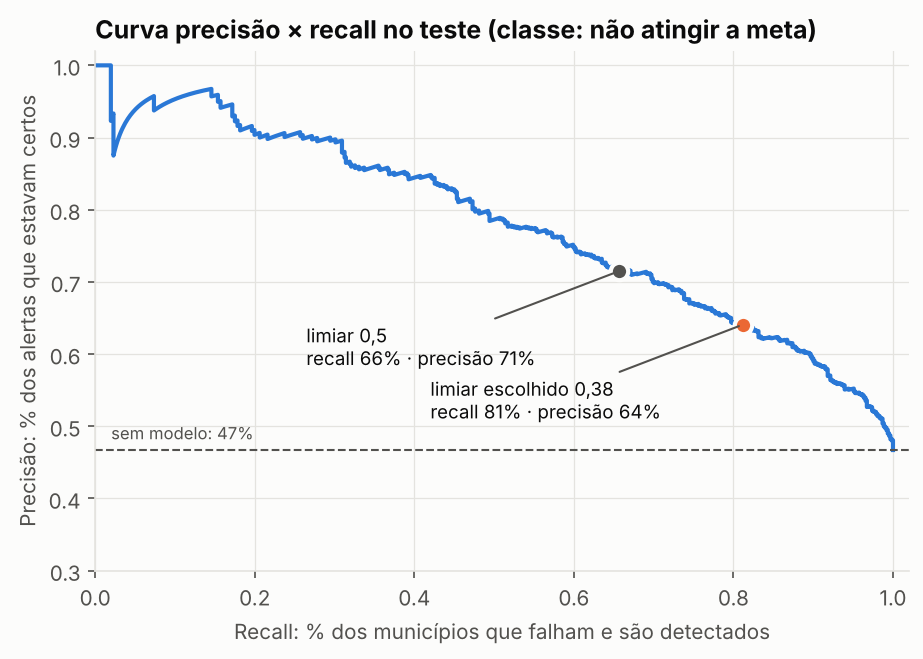

In [3]:
display(Image('images/modelo_precisao_recall.png'))

In [4]:
r['sensibilidade_sem_rs']

{'municipios': 4811,
 'pct_risco': 0.42880897942215757,
 'auc_cv': 0.7471213320172991,
 'auc_teste': 0.7777834196540401}

Sem o RS a AUC cai para ~0,75–0,78: parte do sinal vinha do choque das enchentes.

## Interpretabilidade

In [5]:
i = json.load(open('reports/interpretabilidade.json'))
display(pd.Series(i['permutacao'], name='queda de AUC'))
display(pd.DataFrame(i['estabilidade']))

taxa_atual            1.902e-01
sigla_uf              1.847e-01
media_portugues       5.790e-02
esforco_exigido       5.620e-02
regiao                3.730e-02
participacao          1.300e-02
log_populacao         7.600e-03
log_pib_per_capita    4.000e-04
porte_municipio       4.000e-04
Name: queda de AUC, dtype: float64

,variavel,posicao_media,melhor,pior
0,taxa_atual,1.25,1,2
1,sigla_uf,1.75,1,2
2,media_portugues,3.12,3,4
3,esforco_exigido,3.88,3,4
4,regiao,5.00,5,5
5,participacao,6.00,6,6
6,log_populacao,7.25,7,9
7,log_pib_per_capita,7.88,7,8
8,porte_municipio,8.88,8,9


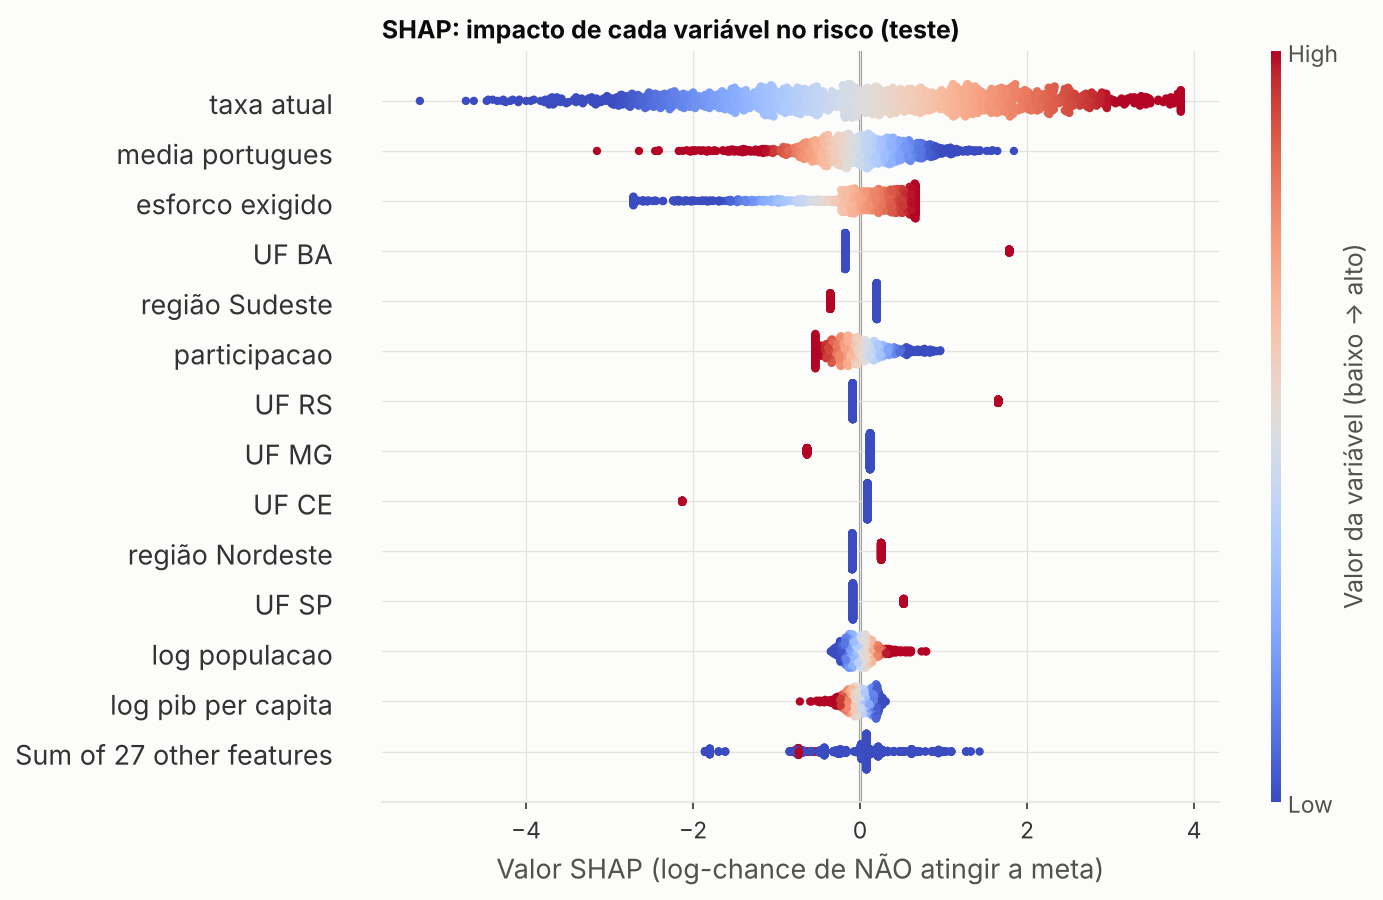

In [6]:
display(Image('images/interp_shap_resumo.png'))

- **Taxa atual** e **UF** se revezam no 1º lugar nas 8 sementes.
- Taxa alta **aumenta** o risco quando o esforço e a média de português são mantidos: é a regressão à média vista na EDA.
- Participação alta reduz o risco. PIB e população quase não pesam.

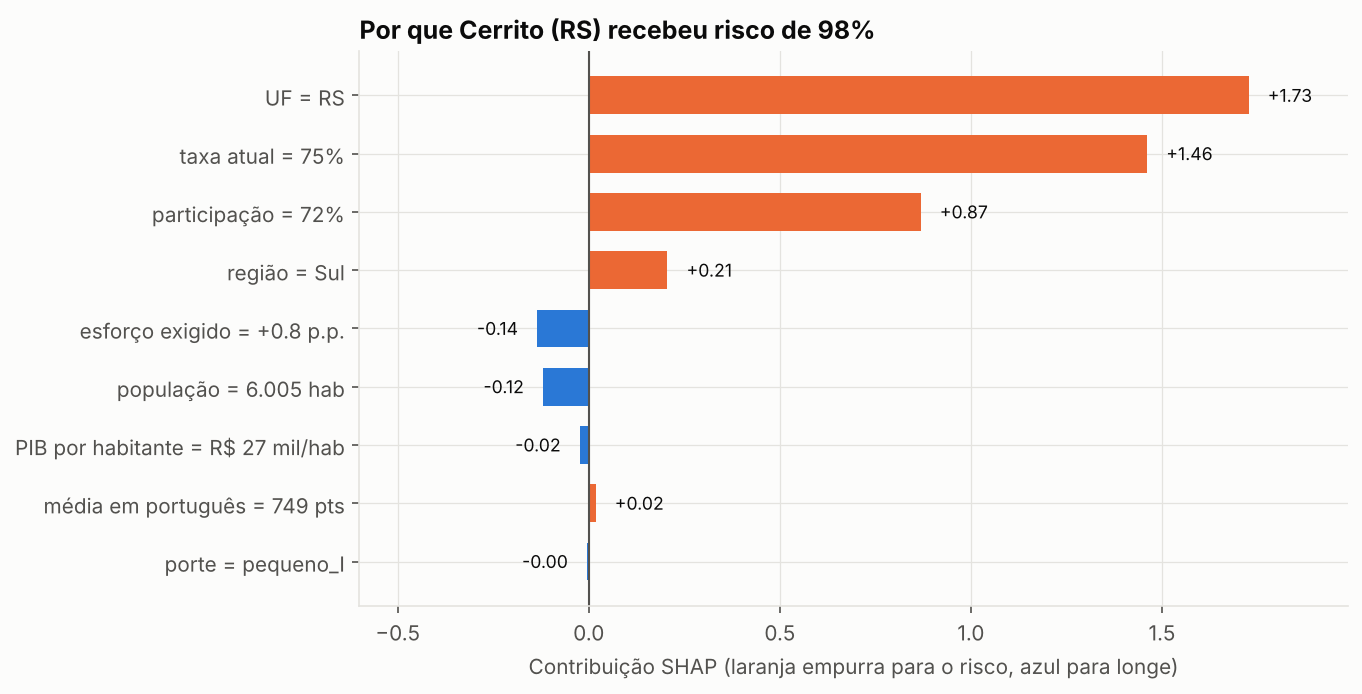

{'id_municipio': '4305124',
 'nome': 'Cerrito',
 'uf': 'RS',
 'contribuicoes': {'sigla_uf': 1.727,
  'taxa_atual': 1.461,
  'participacao': 0.869,
  'regiao': 0.206,
  'media_portugues': 0.018,
  'porte_municipio': -0.004,
  'log_pib_per_capita': -0.023,
  'log_populacao': -0.12,
  'esforco_exigido': -0.135},
 'prob_risco': 0.979}

In [7]:
display(Image('images/interp_shap_municipio.png'))
i['exemplo_shap']

## Aplicação

In [8]:
a = json.load(open('reports/aplicacao.json'))
pd.DataFrame(a['validacao_faixas_2024']).rename(columns={'size': 'municipios', 'mean': 'falharam'})

,faixa,municipios,falharam
0,baixo,1234,0.157
1,moderado,866,0.321
2,alto,2140,0.530
3,critico,992,0.844


As faixas, calculadas fora da amostra, ordenam o risco real: 16% de falha no **baixo**, 84% no **crítico**.

,perfil,municipios,taxa_atual,participacao,esforco_exigido,pct_falhou_2024,nome
0,0,1522,42.21,91.79,5.69,0.38,"baixo desempenho, alta participação"
1,1,593,92.30,93.79,-11.73,0.36,"alto desempenho, alta participação"
2,2,1097,49.54,80.81,4.83,0.59,"baixo desempenho, baixa participação"
3,3,2020,70.86,92.05,1.44,0.49,"desempenho médio, alta participação"


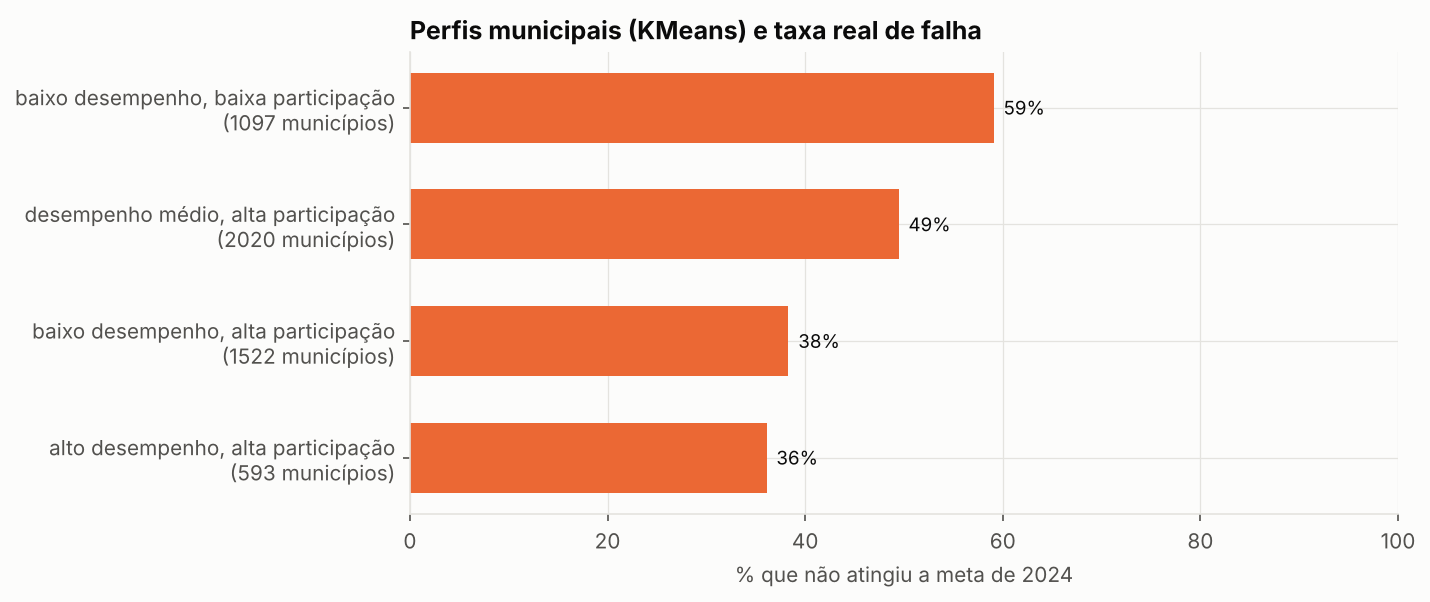

In [9]:
display(pd.read_csv('reports/perfis.csv'))
display(Image('images/aplicacao_perfis.png'))

{'municipios': 5352,
 'faixas': {'baixo': 1675, 'moderado': 908, 'alto': 2152, 'critico': 617},
 'em_alerta': 2769,
 'pct_alerta': 0.5173766816143498,
 'rs_alerta_modelo_completo_pct': 95.69160997732426,
 'rs_alerta_sem_choque_pct': 37.641723356009074,
 'esforco_max_treino': 7.22,
 'pct_esforco_acima_do_treino': 0.35818385650224216}

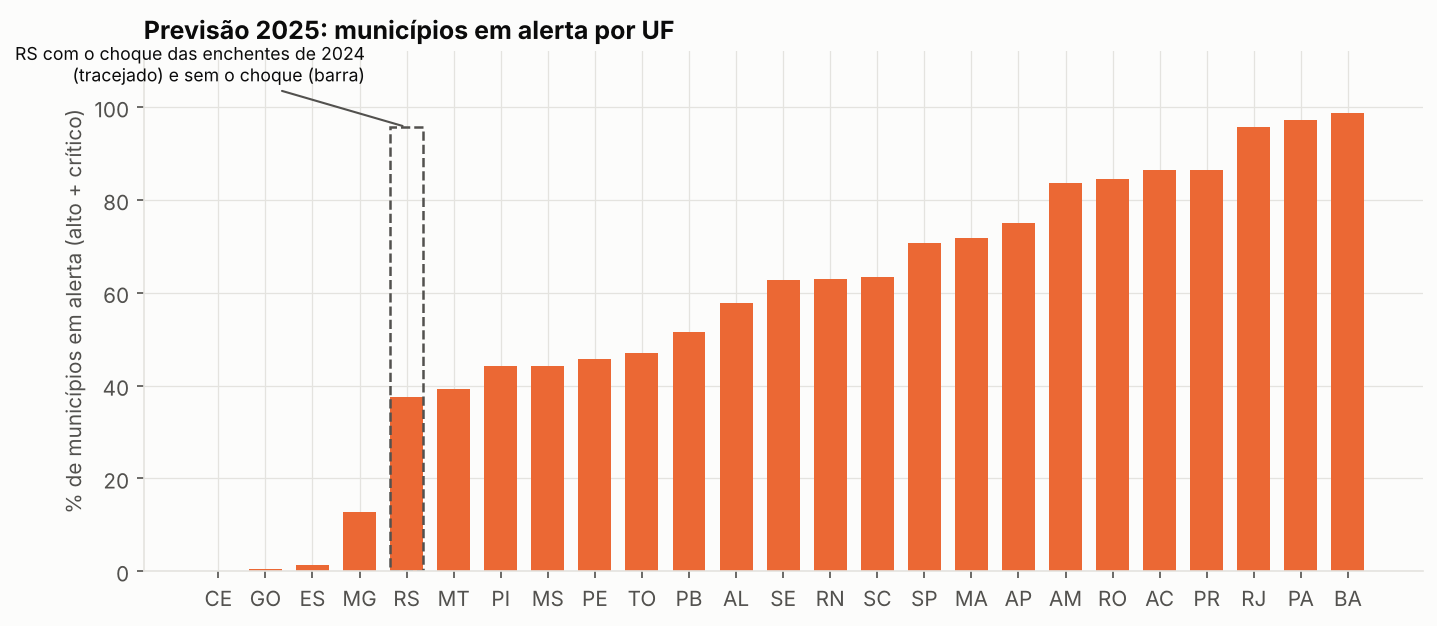

In [10]:
display(a['previsao_2025'])
display(Image('images/aplicacao_alerta_uf_2025.png'))

In [11]:
pd.read_csv('reports/ranking_2025.csv', dtype={'id_municipio': str}).head(15)

,id_municipio,nome_municipio,sigla_uf,regiao,taxa_2024,meta_2025,esforco_exigido,participacao,prob_risco,prob_risco_sem_rs,prob_recomendada,faixa,alerta,perfil_nome,esforco_acima_do_treino,observacao
0,2919405,Licínio de Almeida,BA,Nordeste,65.48,76.51,11.03,88.42,0.970,0.970,0.970,critico,True,"baixo desempenho, alta participação",True,NaN
1,2917409,Jacaraci,BA,Nordeste,56.86,69.00,12.14,81.60,0.968,0.968,0.968,critico,True,"baixo desempenho, baixa participação",True,NaN
2,2931053,Tanque Novo,BA,Nordeste,61.80,68.78,6.98,94.68,0.958,0.957,0.958,critico,True,"baixo desempenho, alta participação",False,NaN
3,2921807,Mortugaba,BA,Nordeste,60.00,72.44,12.44,88.98,0.957,0.957,0.957,critico,True,"baixo desempenho, alta participação",True,NaN
4,2920304,Malhada de Pedras,BA,Nordeste,70.27,73.37,3.10,92.50,0.956,0.956,0.956,critico,True,"desempenho médio, alta participação",False,NaN
5,2904209,Botuporã,BA,Nordeste,47.37,67.88,20.51,71.25,0.947,0.947,0.947,critico,True,"baixo desempenho, baixa participação",True,NaN
6,2902302,Aratuípe,BA,Nordeste,60.00,58.32,-1.68,71.43,0.941,0.941,0.941,critico,True,"baixo desempenho, baixa participação",False,NaN
7,2912004,Ibiassucê,BA,Nordeste,61.19,69.82,8.63,100.00,0.940,0.940,0.940,critico,True,"baixo desempenho, alta participação",True,NaN
8,2920601,Maragogipe,BA,Nordeste,54.49,58.00,3.51,84.34,0.940,0.938,0.940,critico,True,"baixo desempenho, baixa participação",False,NaN
9,2914109,Ipupiara,BA,Nordeste,59.15,70.97,11.82,97.26,0.939,0.939,0.939,critico,True,"baixo desempenho, alta participação",True,NaN
